# Teste de treinamento de modelo para predição de Slump utilizando CatBoost

In [1]:
%%capture
!pip install catboost ipywidgets optuna

In [3]:
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import GroupKFold
from catboost import CatBoostRegressor
import matplotlib.pyplot as plt
from google.colab import drive
from tqdm.notebook import tqdm
import seaborn as sns
import pandas as pd
import numpy as np
import os, optuna

### Montagem do drive

In [4]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
dirpath = '/content/drive/MyDrive/supervised-learning-studies/projeto/slump'
filename = 'df_slump_CatBoost.pkl'
file_path = os.path.join(dirpath, filename)
os.listdir(dirpath)
df = pd.read_pickle(file_path)
df['target'] = df['Slump_mm'].copy()
df.drop(inplace=True, columns=['Slump_mm'])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 98 entries, 5 to 124
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   lubrificacao_efetiva        98 non-null     float64
 1   area_superficial_proxy      98 non-null     float64
 2   vol_areia                   98 non-null     float64
 3   indice_lubrificacao_global  98 non-null     float64
 4   fator_agua_finos            98 non-null     float64
 5   potencial_segregacao        98 non-null     float64
 6   agua_sobre_areia            98 non-null     float64
 7   Agua_kg_m3                  98 non-null     float64
 8   Autores/ano                 98 non-null     object 
 9   vol_cimento                 98 non-null     float64
 10  vol_filer                   98 non-null     float64
 11  Relacao_Agua_Aglomerante    98 non-null     float64
 12  vol_sp                      98 non-null     float64
 13  target                      98 non-null  

In [6]:
n_groups = df['Autores/ano'].nunique()
print(f"Número de grupos únicos (Autores/ano): {n_groups}")
gkf = GroupKFold(n_splits=n_groups)

Número de grupos únicos (Autores/ano): 11


In [ ]:
%%time
X = df.drop(columns=['target', 'Autores/ano'])
y = df['target']
groups = df['Autores/ano']

def objective(trial):

    rmse_scores = []
    hyper_params = {
        'loss_function': 'RMSE',
        'eval_metric': 'RMSE',
        'random_seed': 42,

        'iterations': trial.suggest_int(
            'iterations', 50, 100
        ),

        'learning_rate': trial.suggest_float(
            'learning_rate', 0.001, 0.05, log=True
        ),

        'depth': trial.suggest_int(
            'depth', 10, 15
        ),

        'l2_leaf_reg': trial.suggest_float(
            'l2_leaf_reg', 50, 100, log=True
        ),

        'min_data_in_leaf': trial.suggest_int(
            'min_data_in_leaf', 15, 30
        ),

        'random_strength': trial.suggest_float(
            'random_strength', 15, 40
        ),

        'bagging_temperature': trial.suggest_float(
            'bagging_temperature', 2, 4
        ),

        'rsm': trial.suggest_float(
            'rsm', 0.5, 0.9, log=True
        ),

        'od_type': 'Iter',

        'od_wait': trial.suggest_int(
            'od_wait', 50, 100
        )
    }

    for fold, (train_idx, val_idx) in enumerate(
        gkf.split(X, y, groups)
    ):

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        model = CatBoostRegressor(**hyper_params)

        model.fit(
            X_train,
            y_train,
            verbose=False
        )

        preds = model.predict(X_val)

        rmse_scores.append(
            root_mean_squared_error(y_val, preds)
        )

    return np.mean(rmse_scores)

CPU times: user 1.6 ms, sys: 0 ns, total: 1.6 ms
Wall time: 1.6 ms


In [15]:
# ==========================================
# EXECUTANDO O ESTUDO
# ==========================================
n_trials = 150

pbar = tqdm(total=n_trials, desc="Otimizando")

def tqdm_callback(study, trial):
    pbar.update(1)
    pbar.set_postfix({
        "best_rmse": f"{study.best_value:.4f}"
    })

study = optuna.create_study(
    direction="minimize",
    study_name="Tuning_Concreto"
)

study.optimize(
    objective,
    n_trials=n_trials,
    callbacks=[tqdm_callback]   
)

pbar.close()

print("\n" + "="*50)
print("🏆 OTIMIZAÇÃO CONCLUÍDA")
print("="*50)
print(f"Melhor RMSE alcançado (Cross-Validation): {study.best_value:.4f}")
print("Melhores Hiperparâmetros encontrados:")
for key, value in study.best_params.items():
    print(f"  '{key}': {value},")

Otimizando:   0%|          | 0/150 [00:00<?, ?it/s]

[I 2026-06-04 23:03:38,896] A new study created in memory with name: Tuning_Concreto
[I 2026-06-04 23:03:59,162] Trial 0 finished with value: 34.67209743653098 and parameters: {'iterations': 157, 'learning_rate': 0.0065560977102808735, 'depth': 15, 'l2_leaf_reg': 26.48740082285894, 'min_data_in_leaf': 17, 'random_strength': 10.801839135178483, 'bagging_temperature': 3.1751043164852026, 'rsm': 0.8355554224176849, 'od_wait': 74}. Best is trial 0 with value: 34.67209743653098.
[I 2026-06-04 23:04:14,590] Trial 1 finished with value: 36.041502624741206 and parameters: {'iterations': 303, 'learning_rate': 0.02191715782889245, 'depth': 11, 'l2_leaf_reg': 36.14835643655328, 'min_data_in_leaf': 30, 'random_strength': 16.087316142899653, 'bagging_temperature': 4.497447354771243, 'rsm': 0.8269141000504453, 'od_wait': 74}. Best is trial 0 with value: 34.67209743653098.
[I 2026-06-04 23:04:28,491] Trial 2 finished with value: 37.38614881206801 and parameters: {'iterations': 484, 'learning_rate': 0


🏆 OTIMIZAÇÃO CONCLUÍDA
Melhor RMSE alcançado (Cross-Validation): 34.3062
Melhores Hiperparâmetros encontrados:
  'iterations': 52,
  'learning_rate': 0.0050420744538709076,
  'depth': 12,
  'l2_leaf_reg': 81.16873583222143,
  'min_data_in_leaf': 20,
  'random_strength': 19.318853359285818,
  'bagging_temperature': 3.7794495094280793,
  'rsm': 0.7999269805931805,
  'od_wait': 76,


In [16]:
%%time
X = df.drop(columns=['target', 'Autores/ano'])
y = df['target']
groups = df['Autores/ano']

all_preds = []
all_true = []
all_groups = []
rmse_scores = []

results = []
importancias_cat = []

train_curves = []
val_curves = []

for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    best_params = study.best_params.copy()

    best_params.update({
        'loss_function': 'RMSE',
        'eval_metric': 'RMSE',
        'random_seed': 42,
        'od_type': 'Iter'
    })

    model = CatBoostRegressor(**best_params)

    model.fit(
        X_train,
        y_train,
        verbose=False
    )

    # CURVAS DE APRENDIZADO (RMSE calculado manualmente)
    train_curve = [
        root_mean_squared_error(y_train, pred)
        for pred in model.staged_predict(X_train)
    ]

    val_curve = [
        root_mean_squared_error(y_val, pred)
        for pred in model.staged_predict(X_val)
    ]

    train_curves.append(train_curve)
    val_curves.append(val_curve)

    preds = model.predict(X_val)

    all_preds.extend(preds)

    all_true.extend(y_val)

    rmse_scores.append(
        root_mean_squared_error(y_val, preds)
    )

    all_groups.extend(groups.iloc[val_idx])

    importancias_cat.append(
        model.feature_importances_
    )

CPU times: user 7.76 s, sys: 1.27 s, total: 9.03 s
Wall time: 5.28 s


In [17]:
print(best_params)

{'iterations': 52, 'learning_rate': 0.0050420744538709076, 'depth': 12, 'l2_leaf_reg': 81.16873583222143, 'min_data_in_leaf': 20, 'random_strength': 19.318853359285818, 'bagging_temperature': 3.7794495094280793, 'rsm': 0.7999269805931805, 'od_wait': 76, 'loss_function': 'RMSE', 'eval_metric': 'RMSE', 'random_seed': 42, 'od_type': 'Iter'}


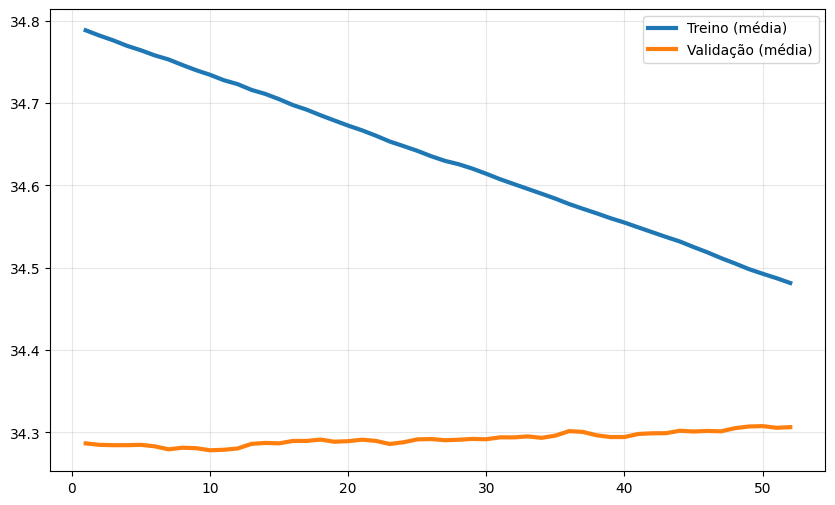

In [34]:
plt.figure(figsize=(10, 6))

plt.plot(
    iterations,
    train_mean,
    color='tab:blue',
    linewidth=3,
    label='Treino (média)'
)

plt.plot(
    iterations,
    val_mean,
    color='tab:orange',
    linewidth=3,
    label='Validação (média)'
)

plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [19]:
# Resumo das curvas de aprendizado por fold
train_final = np.mean([curve[-1] for curve in train_curves if len(curve)])
val_final = np.mean([curve[-1] for curve in val_curves if len(curve)])
overfitting_gap = val_final - train_final

print("\n" + "="*60)
print("📊 RESUMO DAS CURVAS DE APRENDIZADO")
print("="*60)
print("Métrica: último ponto disponível de cada fold")
print(f"✅ RMSE Treino (final por fold):      {train_final:.6f}")
print(f"⚠️  RMSE Validação (final por fold):   {val_final:.6f}")
print(f"📈 Gap (Val - Train):                 {overfitting_gap:.6f}")
print("="*60)


📊 RESUMO DAS CURVAS DE APRENDIZADO
Métrica: último ponto disponível de cada fold
✅ RMSE Treino (final por fold):      34.481361
⚠️  RMSE Validação (final por fold):   34.306231
📈 Gap (Val - Train):                 -0.175130


In [20]:
debug_df = pd.DataFrame({
    'y_true': np.array(all_true),
    'y_pred': np.array(all_preds),
    'group': np.array(all_groups)
})

debug_df['residual'] = (
    debug_df['y_true'] - debug_df['y_pred']

)

debug_df["abs_error"] = (
    debug_df["residual"].abs()
)

In [21]:
oof_rmse = root_mean_squared_error(debug_df["y_true"], debug_df["y_pred"])

print("\n" + "="*60)
print("📌 COMPARAÇÃO CONSISTENTE DE MÉTRICAS")
print("="*60)
print(f"✅ RMSE OOF (todas as previsões fora da amostra): {oof_rmse:.6f}")
print(f"🏆 Melhor RMSE do Optuna (média dos folds):        {study.best_value:.6f}")
print("="*60)


📌 COMPARAÇÃO CONSISTENTE DE MÉTRICAS
✅ RMSE OOF (todas as previsões fora da amostra): 37.259294
🏆 Melhor RMSE do Optuna (média dos folds):        34.306231


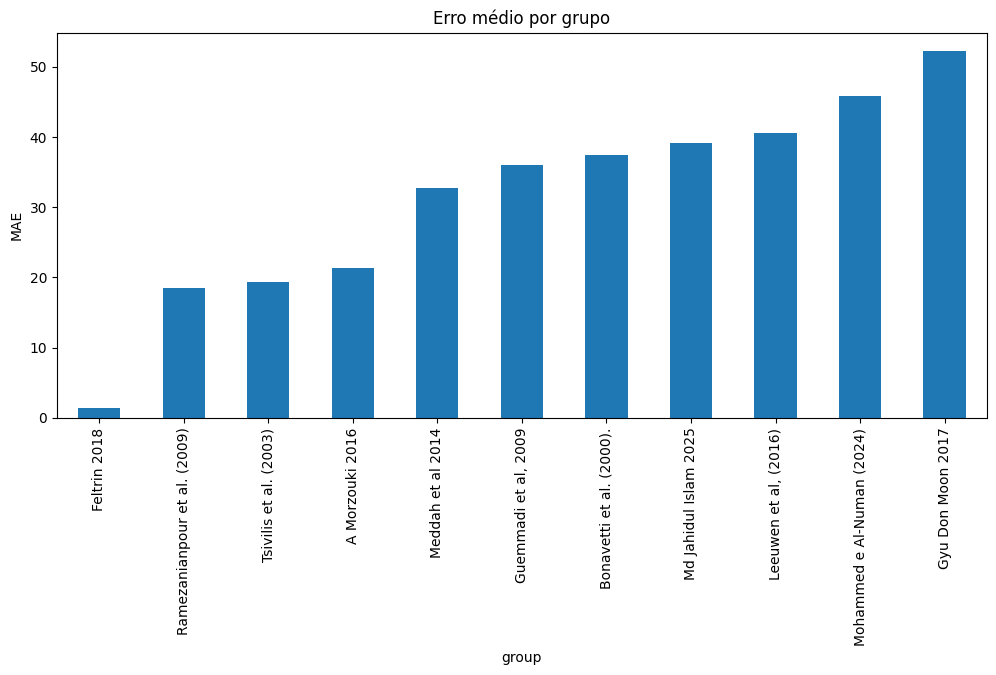

In [22]:
group_errors = (
    debug_df
    .groupby("group")
    ["abs_error"]
    .mean()
    .sort_values()
)
plt.figure(figsize=(12,5))

group_errors.plot(kind="bar")

plt.ylabel("MAE")
plt.title("Erro médio por grupo")
plt.show()

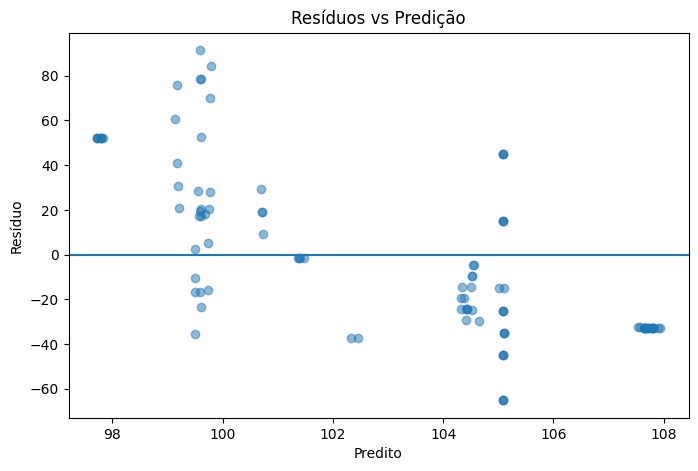

In [23]:
plt.figure(figsize=(8,5))

plt.scatter(
    debug_df["y_pred"],
    debug_df["residual"],
    alpha=0.5
)

plt.axhline(0)

plt.xlabel("Predito")
plt.ylabel("Resíduo")
plt.title("Resíduos vs Predição")
plt.show()

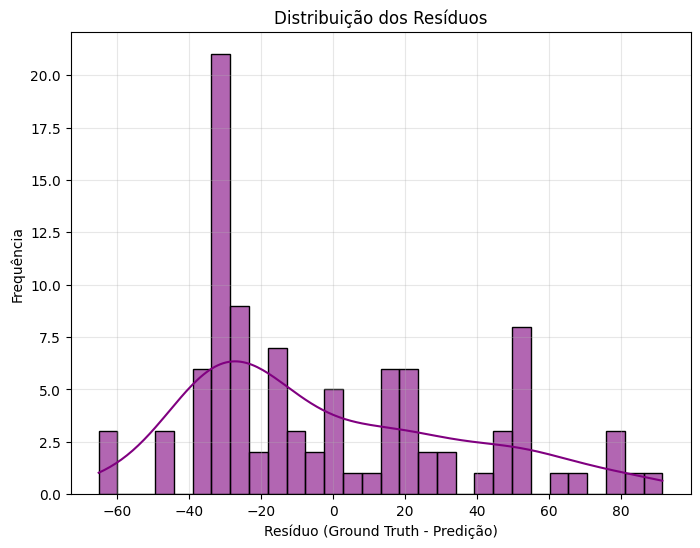

In [24]:
plt.figure(figsize=(8, 6))

sns.histplot(
    debug_df['residual'],
    bins=30,
    kde=True,
    color='purple',
    alpha=0.6
)

plt.title("Distribuição dos Resíduos")
plt.xlabel("Resíduo (Ground Truth - Predição)")
plt.ylabel("Frequência")

plt.grid(True, alpha=0.3)

plt.show()

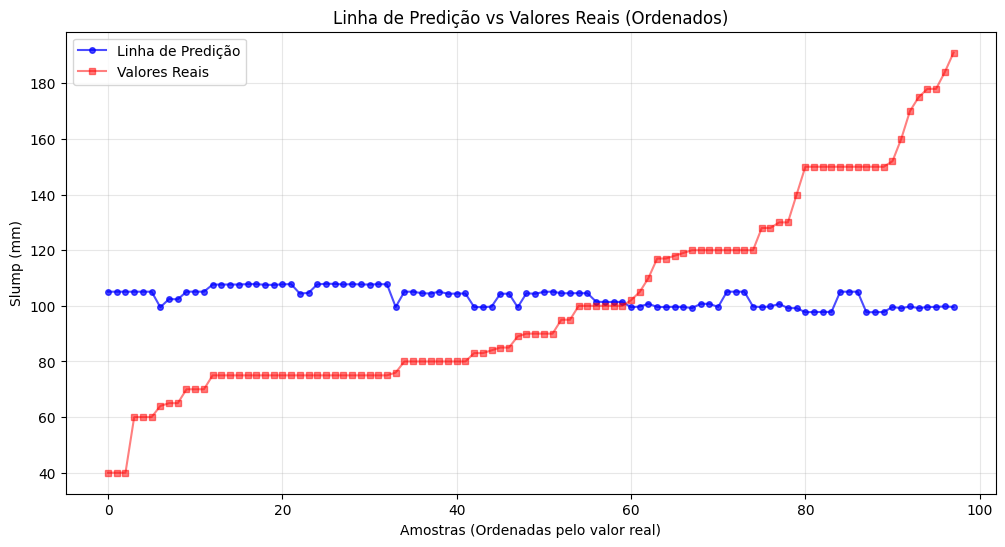

In [25]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
debug_df = debug_df.sort_values(by="y_true").reset_index(drop=True)
indices = range(len(debug_df))

plt.figure(figsize=(12, 6))

# 1. Linha das Predições (conectando os pontos preditos)
plt.plot(indices, debug_df["y_pred"], color='blue', label="Linha de Predição", 
         alpha=0.7, linewidth=1.5, marker='o', markersize=4)

# 2. Pontos dos Valores Reais (Ground Truth)
plt.plot(indices, debug_df["y_true"], color='red', label="Valores Reais", 
            alpha=0.5, linewidth=1.5, marker='s', markersize=4)

plt.title("Linha de Predição vs Valores Reais (Ordenados)")
plt.xlabel("Amostras (Ordenadas pelo valor real)")
plt.ylabel("Slump (mm)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [26]:
r2 = r2_score(debug_df["y_true"], debug_df["y_pred"])
rmse = root_mean_squared_error(debug_df["y_true"], debug_df["y_pred"])
mae = mean_absolute_error(debug_df["y_true"], debug_df["y_pred"])
mape = mean_absolute_percentage_error(debug_df["y_true"], debug_df["y_pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 37.2593
mean_absolute_error: 31.8650
mean_absolute_percentage_error: 0.3496
R² Score: -13.8690


In [27]:
model = CatBoostRegressor(**study.best_params)
model.fit(X, y, verbose=False)

CatBoostRegressor(bagging_temperature=3.7794495094280793, depth=12, iterations=52, l2_leaf_reg=81.16873583222143, learning_rate=0.0050420744538709076, loss_function='RMSE', min_data_in_leaf=20, od_wait=76, random_strength=19.318853359285818, rsm=0.7999269805931805)

/tmp/ipykernel_194839/3575547520.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Feature', data=df_importancia, palette='viridis')


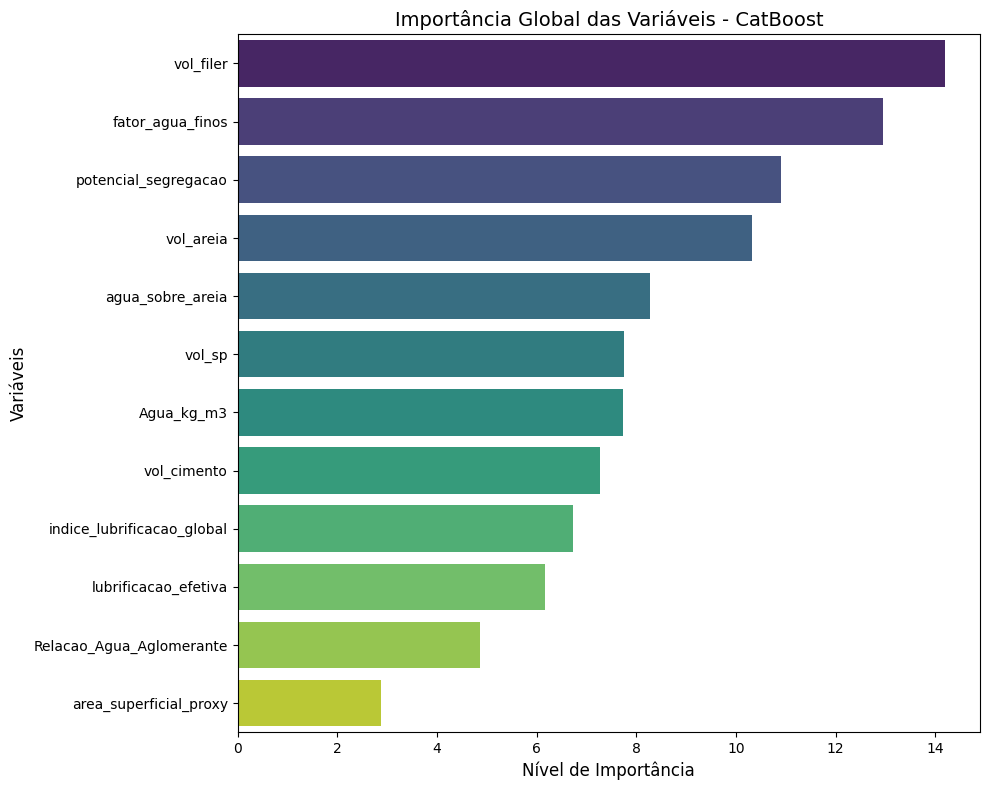

In [28]:
importancias = model.get_feature_importance()
features = X.columns

df_importancia = pd.DataFrame({'Feature': features, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importancia', y='Feature', data=df_importancia, palette='viridis')
plt.title('Importância Global das Variáveis - CatBoost', fontsize=14)
plt.xlabel('Nível de Importância', fontsize=12)
plt.ylabel('Variáveis', fontsize=12)
plt.tight_layout()
plt.show()